In [1]:
using CairoMakie

In [2]:
n = [1, 2, 4]

mem_tot = [59629, (44379+43849), (24658+23069*3)]
mem_per = mem_tot ./ n

times = [1.605*60, (52.466+52.479)/2, (27.904+27.885+27.871+27.906)/4]

3-element Vector{Float64}:
 96.3
 52.4725
 27.8915

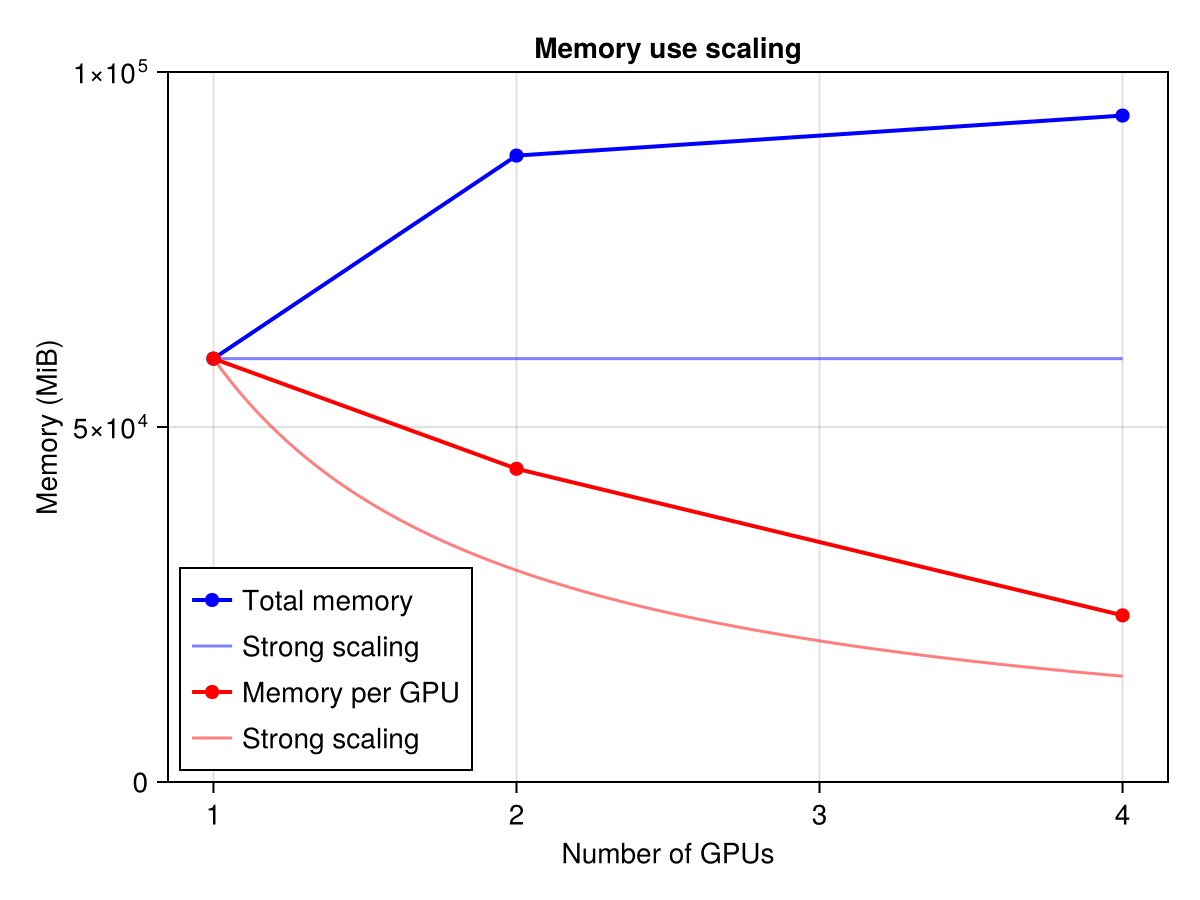

In [3]:
f = Figure()
ax = Axis(f[1, 1], xlabel = "Number of GPUs", ylabel = "Memory (MiB)", title = "Memory use scaling")
scatterlines!(ax, n, mem_tot, linewidth = 2, label = "Total memory", marker = :circle, markersize = 10, color = :blue)
lines!(ax, range(1, 4, 100), range(mem_tot[1], mem_tot[1], 100), color = :blue, label = "Strong scaling", alpha = 0.5)
scatterlines!(ax,
    n,
    mem_per,
    linewidth = 2,
    label = "Memory per GPU",
    marker = :circle,
    markersize = 10,
    color = :red,
)
lines!(ax, range(1, 4, 100), mem_tot[1] ./ range(1, 4, 100), color = :red, label = "Strong scaling", alpha = 0.5)
ylims!(ax, 0, 10^5)
axislegend(ax, position = :lb)
save("mem_strong.svg", f)
f

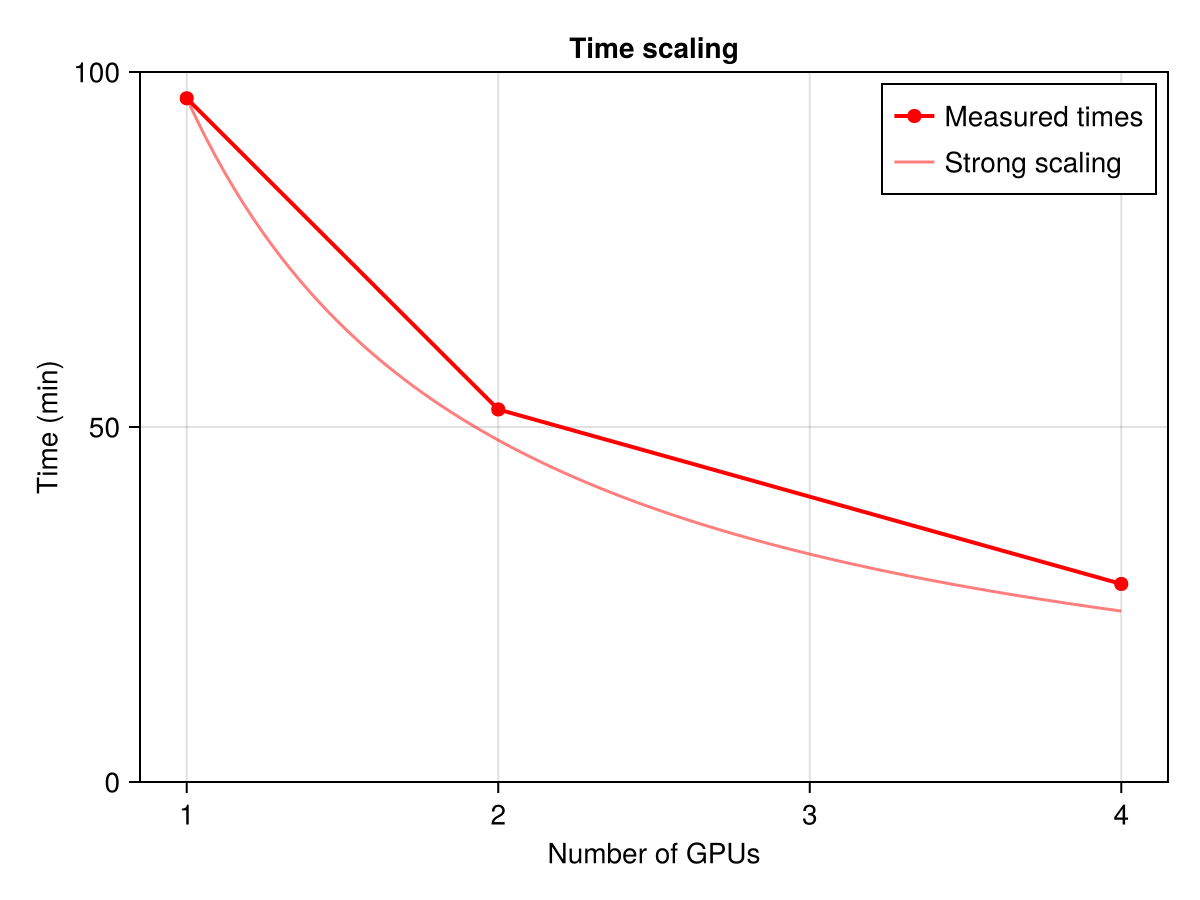

In [7]:
f = Figure()
ax = Axis(f[1, 1], xlabel = "Number of GPUs", ylabel = "Time (min)", title = "Time scaling")
scatterlines!(ax, n, times, linewidth = 2, marker = :circle, markersize = 10, label = "Measured times", color = :red)
lines!(ax, range(1, 4, 100), times[1] ./ range(1, 4, 100), label = "Strong scaling", color = :red, alpha = 0.5)
ylims!(0, 100)
axislegend(ax)
save("time_strong.svg", f)
f